# Lunar Diurnal test case



## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
from pathlib import Path

# Add parent directory to path for imports
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Import thermal model components
from core.config_manager import ConfigManager, create_default_base_config
from core.thermal_simulation import ThermalSimulator
from modelmain import Simulator
from config import SimulationConfig
from modelmain import fit_blackbody_wn_banded, max_btemp_blackbody, emissionT

from radiance_processor import calculate_radiances_from_results, recompute_radiance_with_angles


# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

print("Imports completed successfully!")

Imports completed successfully!


## Create and Load Base Simulation Configuration

Create and load in a default config file. 

In [2]:
# Option 1: Create a new default configuration
config_path = "../configs/base_configs/analysis_template.yaml"

# Create config directory if it doesn't exist
os.makedirs(os.path.dirname(config_path), exist_ok=True)

# Create default configuration for analysis
create_default_base_config(config_path)

# Load the configuration
config_manager = ConfigManager(config_path)

# Create base configuration
base_config = config_manager.create_config()

print(f"Configuration created at: {config_path}")
print(f"Loaded configuration.")


Default configuration saved to: ../configs/base_configs/analysis_template.yaml
Configuration created at: ../configs/base_configs/analysis_template.yaml
Loaded configuration.


## Run Diurnal Sim



In [3]:
# Modify base configuration for our analysis
settings = {
    'diurnal': True,                       # Steady state simulation
    'sun': True,                           # Include solar heating
    'T_fixed': False,                        # Temperature is fixed, prevents thermal evolution
    'enable_diurnal_convergence': False,
    'thermal_evolution_mode': 'two_wave',   #Run thermal evolution later with broadband vis (turned off) and broadband thermal. 
    'RTE_solver': 'disort',
    'output_radiance_mode': 'two_wave',       
    'depth_dependent_properties': False,
    'temperature_dependent_properties': False,
    'temp_dependent_cp': False,
    'temp_dependent_k': False,      #Only use for non-RTE model. Temperature-dependence of conductivity comes naturally in RTE model. 
    'P': 15450,
    'auto_dt': False,
    'tsteps_day': 5000,
    'dtfac': 80000,
    'minsteps': 50000,
    'ndays': 5,
    'observer_mu': 1.0,                     # Observer zenith angle (0 for nadir)
    'k_dust': 5.5e-4,
    'rho_dust': 700.0,
    'cp_dust': 800.0,
    'k_rock': 0.5,
    'rho_rock': 1800.0,
    'cp_rock': 800.0,
    'Et': 7000.0,                          # Mean extinction coefficient. For phi=0.37, 50300. For phi=0.60, 81600. 
    'eta': 1.0,                             #Vis/thermal extinction coefficient ratio. 
    'ssalb_therm': 0.5,                     # Single scattering albedo for thermal radiation (average from mie code)
    'g_therm': 0.75,                         # Asymmetry parameter for thermal radiation (average from mie code)
    'ssalb_vis': 0.55,
    'g_vis': 0.75,
    'R_base': 0.025,                          # Global reflectivity value for substrate     
    'disort_space_temp': 0.0,              # Cold shroud temperature
    'single_layer': False,                   # Use single-layer model
    'dust_thickness': 20.0e-6,                 # 10 cm
    'T_bottom': 260,                        # Sample base fixed at 500 K
    'bottom_bc': 'dirichlet',               # Bottom boundary condition 
    'crater': False,
    'nstr_out': 16,                # Number of streams for output
    'nmom_out': 16,                # Number of moments for output
    'nstr': 4,
    'nmom': 4,
    'fill_frac': 0.37,                      #Fill fraction for particles. 
    'radius': 0.5e-6,                       #Particle radius in meters.
    'mie_file_out': '/Users/ryan/Research/RT_models/RT_thermal_model/Optical_props/serpentine_mie_200wns_1um.txt',  # Mie file for output
    'wn_bounds_out': '/Users/ryan/Research/RT_models/RT_thermal_model/Optical_props/wn_bounds_200.txt',  # Wavenumber bounds for output files,
    'nstr_out': 16,                # Number of streams for output
    'nmom_out': 16,                # Number of moments for output
    'scale_Et': False,
    'freq_out': 96,
    'latitude': np.radians(50.0)
}

# Create configuration with overrides
config1 = config_manager.create_config(settings)

print("Running baseline simulation...")
print(f"Configuration: Et={config1.Et}, k_dust={config1.k_dust}, thickness={config1.dust_thickness}m")

# Run simulation
sim1 = Simulator(config1)
T_out1, phi_vis1, phi_therm1, T_surf1, t_out1 = sim1.run()


print(f"Simulation completed! Output shape: {T_out1.shape}")
print(f"Time range: {t_out1[0]:.0f} to {t_out1[-1]:.0f} seconds")
print(f"Surface temperature range: {T_surf1.min():.1f} to {T_surf1.max():.1f} K")

Running baseline simulation...
Configuration: Et=7000.0, k_dust=0.00055, thickness=2e-05m
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000
Time step 20000/25000
Time step 21250/25000
Time step 22500/25000
Time step 23750/25000
Simulation completed in 2.55 s
Simulation completed! Output shape: (98, 96)
Time range: 61800 to 77250 seconds
Surface temperature range: 240.9 to 285.4 K


## Calibrate ssalb_vis against Bennu bond albedo

Uses `Analyses/spectral_calibration.py`, which reuses `Simulator.compute_spectral_properties`
(modelmain.py) for a single lightweight, isothermal RTE flux calculation — no time-stepping
required. Upward visible flux with the sun straight overhead gives the bond albedo; upward
thermal flux with no sun gives the thermal emissivity. Both are computed for the same
dust-over-substrate column configured above (`config1`), varying only `ssalb_vis`.

The emissivity value reported here is a useful sanity check on `ssalb_therm`/`g_therm`
independent of the albedo calibration, since it doesn't depend on `ssalb_vis` at all.

In [4]:
from spectral_calibration import effective_albedo_emissivity, solve_ssalb_vis

# Baseline check with the guessed ssalb_vis used above
albedo_guess, emissivity_guess, _ = effective_albedo_emissivity(config1)
print(f"Guessed ssalb_vis={config1.ssalb_vis}: bond albedo={albedo_guess:.4f}, "
      f"thermal emissivity={emissivity_guess:.4f}")

target_bond_albedo = 0.025

if target_bond_albedo is not None:
    best_ssalb_vis = solve_ssalb_vis(config1, target_bond_albedo)
    print(f"Best-fit ssalb_vis for target bond albedo {target_bond_albedo}: "
          f"{best_ssalb_vis:.6f}")

    # Verify by plugging the solved value back in
    import copy
    cfg_solved = copy.deepcopy(config1)
    cfg_solved.ssalb_vis = best_ssalb_vis
    cfg_solved.__post_init__()
    albedo_solved, emissivity_solved, _ = effective_albedo_emissivity(cfg_solved)
    print(f"Verification: albedo={albedo_solved:.4f} (target {target_bond_albedo}), "
          f"emissivity={emissivity_solved:.4f}")
else:
    print("Set target_bond_albedo above to solve for the matching ssalb_vis.")

Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Guessed ssalb_vis=0.55: bond albedo=0.0246, thermal emissivity=0.9638
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Best-fit ssalb_vis for target bond albedo 0.025: 0.571781
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Verification: albedo=0.0250 (target 

## Calibrate Et and eta for hybrid-mode (Mie-derived) optical properties

Grid spacing is built once from `cfg.Et` (grid.py), before any Mie file is read - even in
hybrid mode, every wavelength band shares the same grid; DISORT only rescales each layer's
optical depth per-wavelength via the Mie `Cext` values, it never changes the number of layers
or their relative spacing. So a representative scalar `Et` still needs to be chosen from the
(wavelength-dependent) Mie data for sensible grid resolution.

`Analyses/hybrid_calibration.py`:
- `set_thermal_Et_from_mie` computes `Et(lambda) = n_p * Cext(lambda) * 1e-12` from the Mie
  file and averages it over the wavelengths that survive `hybrid_wavelength_cutoff` filtering
  at runtime (the actual "thermal" subset DISORT will use), then sets `cfg.Et` to the mean.
- `set_eta_geometric_optics` sets `cfg.eta = Et_visible / cfg.Et`, where
  `Et_visible = 3*fill_frac*Qext/(4*radius)` assumes pure geometric-optics extinction (`Qext=2`).
- `write_thermal_wn_bounds_file` works around a gotcha found while testing this: DISORT filters
  the Mie arrays to `hybrid_wavelength_cutoff` at runtime, but does **not** filter `wn_bounds` to
  match - if any rows get filtered out, the original wn_bounds file no longer matches the
  surviving row count, and hybrid-mode construction raises a bin-count mismatch unless a
  pre-filtered companion `wn_bounds` file is supplied. `hybrid_wavelength_cutoff`'s default is
  now a conservative 0.1 um (down from an original 3.33 um), so in practice almost nothing gets
  filtered out of `serpentine_mie_200wns_1um.txt` by default - see the note below the next
  section for why the cutoff no longer needs to exclude anything for correctness, only for
  compute efficiency.

The printed `Et`/`eta` values below are diagnostics - copy them into the `settings` dict above
(along with `thermal_evolution_mode='hybrid'`, `mie_file`, and the filtered `wn_bounds` path) to
run the real hybrid simulation, same pattern as the `ssalb_vis` calibration above.

In [5]:
import copy
from hybrid_calibration import set_thermal_Et_from_mie, set_eta_geometric_optics, write_thermal_wn_bounds_file

mie_file = '../Optical_props/serpentine_mie_200wns_1um.txt'
wn_bounds_full = '../Optical_props/wn_bounds_200.txt'

# Work on a copy so config1 (already calibrated for ssalb_vis/bond albedo above) isn't disturbed.
cfg_hybrid_calib = copy.deepcopy(config1)
cfg_hybrid_calib.mie_file = mie_file

set_thermal_Et_from_mie(cfg_hybrid_calib, method='mean')
print(f"Reference Et from Mie file (mean over thermal subset): {cfg_hybrid_calib.Et:.1f}")

cfg_hybrid_calib, Et_vis = set_eta_geometric_optics(cfg_hybrid_calib)
print(f"Geometric-optics visible Et: {Et_vis:.1f} -> eta = {cfg_hybrid_calib.eta:.5f}")

wn_bounds_thermal = write_thermal_wn_bounds_file(
    wn_bounds_full, mie_file, cfg_hybrid_calib.hybrid_wavelength_cutoff,
    f"../Optical_props/wn_bounds_200_thermal_{cfg_hybrid_calib.hybrid_wavelength_cutoff}um.txt"
)
cfg_hybrid_calib.wn_bounds = wn_bounds_thermal
print(f"Filtered thermal wn_bounds file: {wn_bounds_thermal}")

print()
print("To run the real hybrid simulation, copy into the settings dict above:")
print(f"  thermal_evolution_mode = 'hybrid'")
print(f"  mie_file = '{mie_file}'")
print(f"  wn_bounds = '{wn_bounds_thermal}'")
print(f"  Et = {cfg_hybrid_calib.Et:.1f}")
print(f"  eta = {cfg_hybrid_calib.eta:.5f}")

Reference Et from Mie file (mean over thermal subset): 130713.8
Geometric-optics visible Et: 1110000.0 -> eta = 8.49183
Filtered thermal wn_bounds file: ../Optical_props/wn_bounds_200_thermal_0.1um.txt

To run the real hybrid simulation, copy into the settings dict above:
  thermal_evolution_mode = 'hybrid'
  mie_file = '../Optical_props/serpentine_mie_200wns_1um.txt'
  wn_bounds = '../Optical_props/wn_bounds_200_thermal_0.1um.txt'
  Et = 130713.8
  eta = 8.49183


## Verify two_wave and hybrid modes agree with equivalent optical properties

`config.py` already has a `scale_Et` option: when set, DISORT rescales every hybrid-thermal
band's `Et(lambda)` so their mean exactly equals `cfg.Et`. If the Mie table is also flattened
to constant `ssalb`/`g`, "mean of identical values" means *every* band gets `Et(lambda)=cfg.Et`
exactly - making each hybrid-thermal band physically identical to a two_wave band, with no
core-code changes.

`write_flat_mie_file` builds that flattened companion table (same wavelength grid, constant
properties), and `compare_two_wave_vs_hybrid` runs a single no-time-stepping RTE flux/source-term
calculation in both modes for direct comparison.

In [6]:
from hybrid_calibration import thermal_mean_properties, write_flat_mie_file, compare_two_wave_vs_hybrid

ssalb_therm_mean, g_therm_mean = thermal_mean_properties(mie_file, cfg_hybrid_calib.hybrid_wavelength_cutoff)
print(f"Mean thermal-subset ssalb={ssalb_therm_mean:.4f}, g={g_therm_mean:.4f}")

flat_mie_path = write_flat_mie_file(
    mie_file, '../Optical_props/serpentine_flat_verification.txt',
    ssalb_therm_mean, g_therm_mean
)

verify_result = compare_two_wave_vs_hybrid(cfg_hybrid_calib, flat_mie_path, ssalb_therm_mean, g_therm_mean)

flux_2w = float(verify_result['flux_up_two_wave'][0])
flux_hy = float(verify_result['flux_up_hybrid_total'])
rel_diff = abs(flux_2w - flux_hy) / flux_2w
print(f"Upward thermal flux: two_wave={flux_2w:.4f}, hybrid(flat)={flux_hy:.4f}, "
      f"relative difference={rel_diff*100:.3f}%")
print("A small nonzero residual is expected here: two_wave integrates Planck emission over a "
      "very wide band (20-10000 cm^-1), while the hybrid thermal band is limited to whatever "
      "wavenumber range the Mie file actually covers - any Planck flux outside that range can't "
      "be captured in hybrid mode. For T_bottom=260K this spectral-truncation effect alone "
      "accounts for a few tenths of a percent - if you see a much larger discrepancy, something "
      "else (grid, scale_Et, wn_bounds mismatch) is likely wrong.")

Mean thermal-subset ssalb=0.3774, g=0.1394
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step: 3.090124 s, Steps per day: 5000
Multi_wave mean Et rescaled to user input value!
Thermal evolution mode: hybrid
Upward thermal flux: two_wave=236.2498, hybrid(flat)=235.3777, relative difference=0.369%
A small nonzero residual is expected here: two_wave integrates Planck emission over a very wide band (20-10000 cm^-1), while the hybrid thermal band is limited to whatever wavenumber range the Mie file actually covers - any Planck flux outside that range can't be captured in hybrid mode. For T_bottom=260K this spectral-truncation effect alone accounts for a few tenths of a percent - if you see a much larger discrepancy, something else (grid, scale_Et, wn_bounds mismatch) is likely wrong.


## Verify two_wave and hybrid diurnal thermal evolution agree

The single-flux check above only exercises the RTE math at one static temperature profile with
no time-stepping. This runs both modes through the *actual* multi-day diurnal loop - sun cycling
on and off every step - which is the real test of whether the two produce equivalent thermal
histories, not just equivalent instantaneous fluxes.

This first real diurnal run in hybrid mode surfaced three bugs in the sun-handling code, now
fixed in `rte_disort.py`/`modelmain.py`:
- The hybrid *visible* solver never actually received solar flux (`planck` silently defaulted to
  `True` instead of `False` for it in `Simulator._setup_thermal_evolution_solvers`).
- The hybrid *thermal* solver received a spurious full extra copy of the broadband solar constant
  whenever the sun was up (`disort_run`'s multi-wave branch didn't check `self.planck` before
  injecting a "broadband approximation" fallback).
- `Simulator.run()`'s `T_surf` calculation used `flux_up_therm[0]`, which for a multi-wave/hybrid
  thermal solver picks out only the *first wavelength band's* flux rather than the bolometric sum
  across all bands - this crashed outright (inhomogeneous `T_surf_history`) before being fixed.

`hybrid_wavelength_cutoff`'s default was also relaxed from 3.33 to 0.1 um: now that the thermal
instance never receives solar flux regardless of which wavelengths it covers, the cutoff is
purely a compute-efficiency knob (avoiding "dead" bands with negligible Planck emission at
short wavelengths), not a correctness requirement, so there's no reason to exclude most of the
Mie file by default anymore.

**On brightness temperature - three different quantities, not one.** An earlier version of this
note claimed `T_surf` "can't distinguish a semi-transparent, depth-graded medium from an opaque
blackbody surface." That overstated the problem and was corrected after re-checking the actual
DISORT plumbing (`rte_disort.py:disort_run`): `T_surf = (flux_up/sigma)**0.25`, where `flux_up`
is DISORT's real *hemispherically-integrated upward flux* at the top of the column - a genuine,
self-consistent RT output that already reflects whatever subsurface/semi-transparent emission
DISORT computed. It is **not** a top-node-kinetic-temperature/opaque-surface proxy (that would be
`self.T[0]`/`T_out[0,:]`, a different quantity the code keeps separate). What `T_surf` actually
lacks is (a) viewing-angle information - it's a hemispheric integral, not what a specific observer
at a specific angle sees - and (b) spectral information - in hybrid mode it's summed across all
bands into one bolometric number, so it can't reveal how the emission peak shifts with wavelength
(the depth-sampling effect central to Christiansen-feature behavior).

So there are three genuinely different comparisons below, computed by `run_diurnal_comparison`:
- **`T_surf_*`**: hemispheric-flux-based, as above. A fair, apples-to-apples two_wave-vs-hybrid
  check on overall RT energy balance.
- **`Tb_bol_*`** (`bolometric_brightness_temperature_series`): DISORT's actual *directional*
  radiance at the chosen observer angle (`gather_rad()`, not `flux_up` - confirmed via
  `rte_disort.py`'s `user_mu`/`user_phi` wiring that this genuinely varies with the angle you
  request, not "fixed at zenith" as an old code comment claimed), summed across all spectral bands
  and inverted via `(radiance*pi/sigma)**0.25`. This is the direct multi-wave generalization of
  the original two_wave-only `(radiance*pi/sigma)**0.25` calculation further down this notebook -
  also a fair, apples-to-apples two_wave-vs-hybrid check, just for the directional (rather than
  hemispheric) quantity.
- **`Tb_max_*`** (`max_brightness_temperature_series`): inverts *each spectral band separately*
  and takes the **maximum** across bands (within a `wn_range` restricted to a genuinely observable
  thermal-IR window, default 400-2000 cm^-1/5-25 um) - the standard "Christiansen feature"
  technique for recovering the least-biased estimate of near-surface temperature from a
  semi-transparent, depth-graded medium. This is **not** a two_wave-vs-hybrid consistency check -
  two_wave has only one band, so there's no spectral peak for it to reveal. A difference between
  `Tb_max_hybrid` and `T_surf`/`Tb_bol` is an expected, genuine finding about hybrid's spectral
  behavior, not disagreement between the models.

(Aside on why `Tb_max` needed the `wn_range` restriction: an *unrestricted* max-across-bands
search is not physically meaningful. Bands deep in the Wien tail (e.g. ~1 um, for a ~200-300K
surface) turned out not to be numerically unreliable - their tiny radiance values were checked
directly against `modelmain.planck_wn_integrated` at the simulation's actual node temperatures and
are real, physically consistent (if minuscule) thermal emission, not noise. The issue is that with
a genuine temperature gradient through the depth of the column, Planck's function is so nonlinear
at short wavelengths that emission there becomes dominated almost entirely by the single hottest
node (Jensen's-inequality-like behavior) - so an unrestricted search doesn't converge to a stable
answer, it trends toward the hottest node in the profile as you push to shorter wavelengths,
limited only by how far the Mie file happens to extend. No real instrument has sensitivity to a
~300K surface at ~1e-16 W/m^2/sr/cm^-1 (1 um), so the search must be restricted to a genuinely
observable window.)

Also worth knowing: `radiance_processor.py` already had machinery for a `Tb_max`-style answer
(`results['brightness_temps']`, via `_fit_brightness_temperature` calling
`modelmain.max_btemp_blackbody`) but it was silently broken - the `MinimalSim` proxy object it
builds lacks a `T_out` attribute that `max_btemp_blackbody` requires, so it always raised
`AttributeError` and silently fell back to a crude non-spectral Stefan-Boltzmann estimate.
Separately, `radiance_processor.py`'s `_get_disort_solver` hardcoded `planck=True` for *every*
solver it built, including visible-band ones - meaning `radiance_visible`/`flux_visible` output
never actually received solar flux either (now fixed to set `planck=False` for
`spectral_component='visible_only'`). `max_brightness_temperature_series`
(`hybrid_calibration.py`) reimplements the same per-band Christiansen technique as a vectorized
Simpson's-rule lookup table instead (validated to <0.0001 K against
`modelmain.planck_wn_integrated`'s quad-based integration, and far faster).

Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000
Time step 20000/25000
Time step 21250/25000
Time step 22500/25000
Time step 23750/25000
Simulation completed in 3.64 s
Time step: 3.090124 s, Steps per day: 5000
Multi_wave mean Et rescaled to user input value!
Thermal evolution mode: hybrid
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000


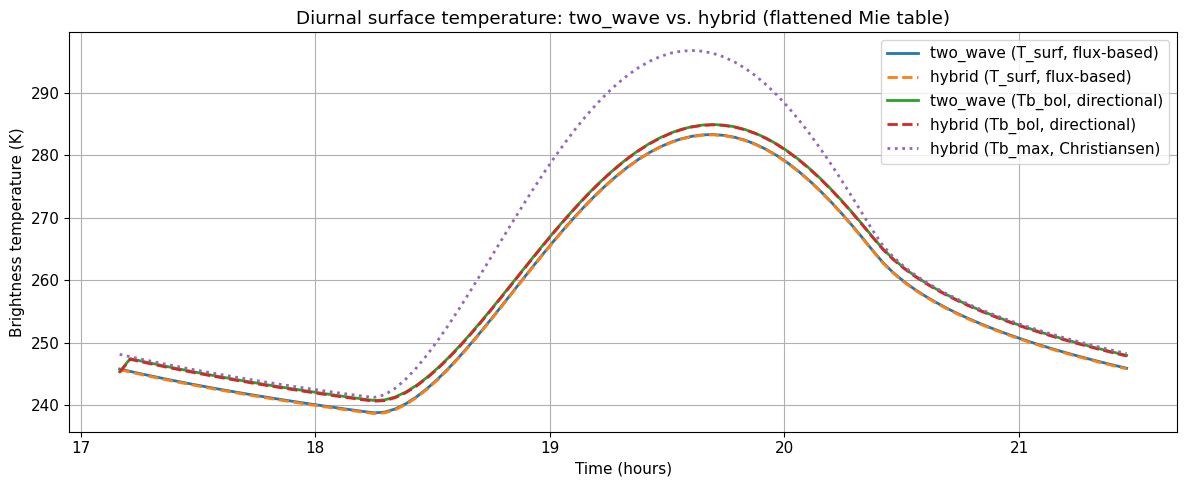

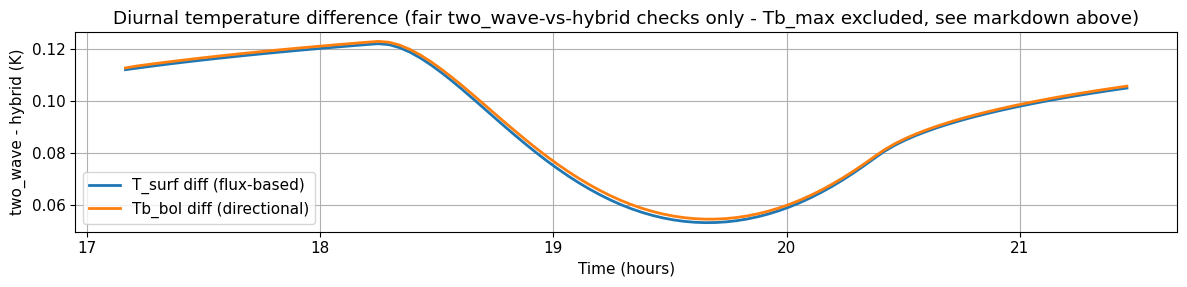

In [7]:
from hybrid_calibration import run_diurnal_comparison

diurnal_result = run_diurnal_comparison(cfg_hybrid_calib, flat_mie_path, ssalb_therm_mean, g_therm_mean)

print(f"Max abs T_surf difference (internal hemispheric-flux based): "
      f"{diurnal_result['max_abs_T_surf_diff']:.4f} K")
print(f"Max abs Tb_bol difference (actual DISORT nadir radiance, bolometric): "
      f"{diurnal_result['max_abs_Tb_bol_diff']:.4f} K")
print(f"Max abs Tb_max difference (actual DISORT nadir radiance, max-across-bands, "
      f"NOT expected to match - see markdown above): "
      f"{diurnal_result['max_abs_Tb_max_diff']:.4f} K")

plt.figure(figsize=(12, 5))
t_hours = diurnal_result['t_out_two_wave'] / 3600
plt.plot(t_hours, diurnal_result['T_surf_two_wave'], label='two_wave (T_surf, flux-based)', linewidth=2)
plt.plot(t_hours, diurnal_result['T_surf_hybrid'], label='hybrid (T_surf, flux-based)', linestyle='--', linewidth=2)
plt.plot(t_hours, diurnal_result['Tb_bol_two_wave'], label='two_wave (Tb_bol, directional)', linewidth=2)
plt.plot(t_hours, diurnal_result['Tb_bol_hybrid'], label='hybrid (Tb_bol, directional)', linestyle='--', linewidth=2)
plt.plot(t_hours, diurnal_result['Tb_max_hybrid'], label='hybrid (Tb_max, Christiansen)', linestyle=':', linewidth=2)
plt.xlabel('Time (hours)')
plt.ylabel('Brightness temperature (K)')
plt.title('Diurnal surface temperature: two_wave vs. hybrid (flattened Mie table)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(t_hours, diurnal_result['T_surf_two_wave'] - diurnal_result['T_surf_hybrid'], label='T_surf diff (flux-based)')
plt.plot(t_hours, diurnal_result['Tb_bol_two_wave'] - diurnal_result['Tb_bol_hybrid'], label='Tb_bol diff (directional)')
plt.xlabel('Time (hours)')
plt.ylabel('two_wave - hybrid (K)')
plt.title('Diurnal temperature difference (fair two_wave-vs-hybrid checks only - Tb_max excluded, see markdown above)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Real spectral comparison: full-resolution Mie file vs. two_wave

Now that the plumbing is verified against a flattened Mie table, run the *actual*
`serpentine_mie_200wns_1um.txt` data (real per-wavelength ssalb/g/Cext, not flattened) in hybrid
mode and compare against two_wave using the mean thermal properties (`ssalb_therm_mean`/
`g_therm_mean`) - i.e., how much does spectrally-resolved absorption/scattering actually change
the diurnal thermal behavior relative to a single broadband-average approximation?

Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000
Time step 20000/25000
Time step 21250/25000
Time step 22500/25000
Time step 23750/25000
Simulation completed in 3.71 s
Time step: 3.090124 s, Steps per day: 5000
Multi_wave mean Et rescaled to user input value!
Thermal evolution mode: hybrid
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000


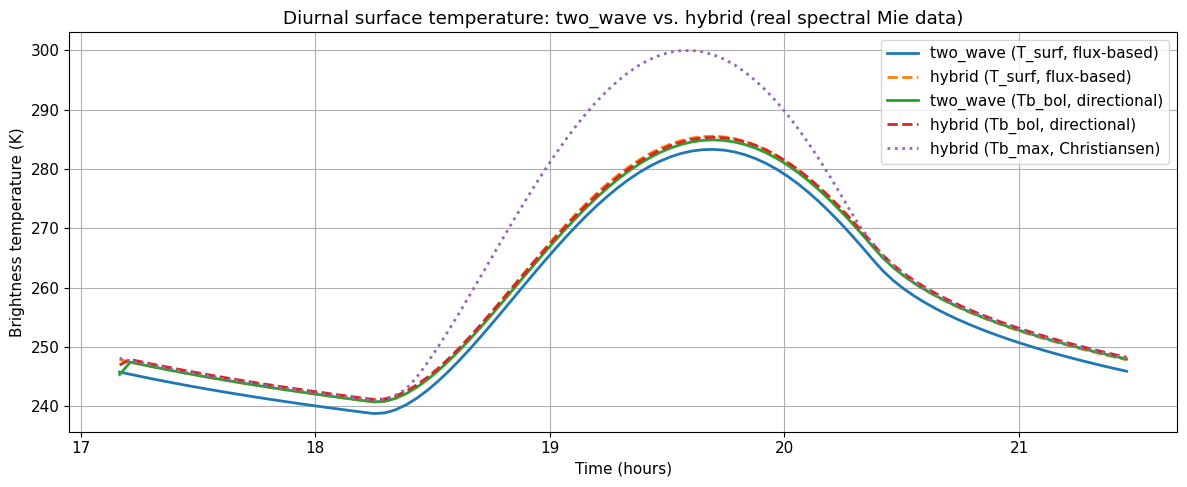

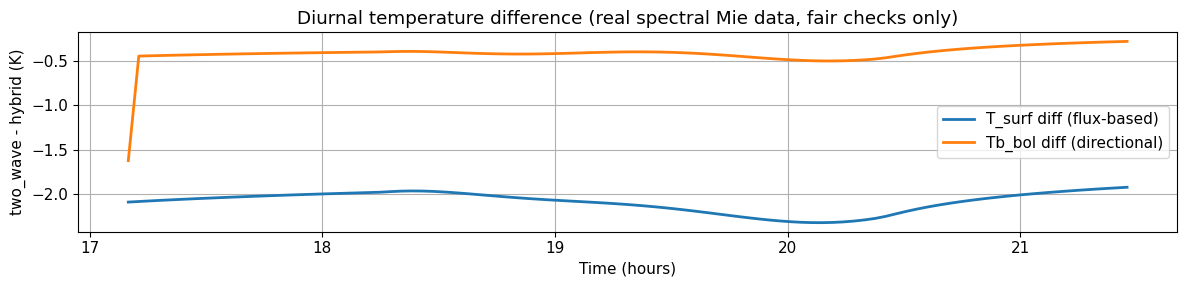

In [8]:
real_spectral_result = run_diurnal_comparison(
    cfg_hybrid_calib, mie_file, ssalb_therm_mean, g_therm_mean, scale_Et=True
)

print(f"Max abs T_surf difference (flux-based), real spectral hybrid vs two_wave (mean props): "
      f"{real_spectral_result['max_abs_T_surf_diff']:.4f} K")
print(f"Max abs Tb_bol difference (directional, bolometric), real spectral hybrid vs "
      f"two_wave (mean props): {real_spectral_result['max_abs_Tb_bol_diff']:.4f} K")
print(f"Max abs Tb_max difference (directional, Christiansen max-across-bands, NOT a "
      f"two_wave-vs-hybrid consistency check - see markdown above): "
      f"{real_spectral_result['max_abs_Tb_max_diff']:.4f} K")

t_hours = real_spectral_result['t_out_two_wave'] / 3600
plt.figure(figsize=(12, 5))
plt.plot(t_hours, real_spectral_result['T_surf_two_wave'], label='two_wave (T_surf, flux-based)', linewidth=2)
plt.plot(t_hours, real_spectral_result['T_surf_hybrid'], label='hybrid (T_surf, flux-based)',
         linestyle='--', linewidth=2)
plt.plot(t_hours, real_spectral_result['Tb_bol_two_wave'], label='two_wave (Tb_bol, directional)', linewidth=2)
plt.plot(t_hours, real_spectral_result['Tb_bol_hybrid'], label='hybrid (Tb_bol, directional)',
         linestyle='--', linewidth=2)
plt.plot(t_hours, real_spectral_result['Tb_max_hybrid'], label='hybrid (Tb_max, Christiansen)',
         linestyle=':', linewidth=2)
plt.xlabel('Time (hours)')
plt.ylabel('Brightness temperature (K)')
plt.title('Diurnal surface temperature: two_wave vs. hybrid (real spectral Mie data)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(t_hours, real_spectral_result['T_surf_two_wave'] - real_spectral_result['T_surf_hybrid'],
         label='T_surf diff (flux-based)')
plt.plot(t_hours, real_spectral_result['Tb_bol_two_wave'] - real_spectral_result['Tb_bol_hybrid'],
         label='Tb_bol diff (directional)')
plt.xlabel('Time (hours)')
plt.ylabel('two_wave - hybrid (K)')
plt.title('Diurnal temperature difference (real spectral Mie data, fair checks only)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Downsampling the Mie file to speed up hybrid runs

The full 200-band hybrid run above takes roughly 10x longer than two_wave. `downsample_mie_file`
groups the wavenumber-sorted rows into N contiguous chunks and replaces each with a simple
(unweighted) mean g/Cext/ssalb - a coarse but fast approximation of the real spectrum.
`downsample_mie_file` expects the **original, unfiltered** wn_bounds file (matching the full
Mie file's row count) - not `cfg_hybrid_calib.wn_bounds`, which may already be filtered to a
`hybrid_wavelength_cutoff`-dependent subset with a different row count (this is exactly what
caused a `ValueError` here previously). `write_thermal_wn_bounds_file` is then chained on the
downsampled output to (re-)apply that filtering consistently, matching the same pattern used for
the original 200-band file above.

Compare each downsampled run against the full 200-band result (not two_wave) to see how much
detail survives at a given band count - **for both** the bulk flux-based `T_surf` and, more
importantly, the max-across-bands Christiansen brightness temperature `Tb_max` (which is far more
sensitive to spectral resolution: the bulk energy budget is well-approximated by a handful of
bands, but the spectral peak that `Tb_max` picks out needs much finer sampling to resolve
properly).

Time step: 3.090124 s, Steps per day: 5000
Multi_wave mean Et rescaled to user input value!
Thermal evolution mode: hybrid
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000
Time step 20000/25000
Time step 21250/25000
Time step 22500/25000
Time step 23750/25000
Simulation completed in 5.35 s
Auto-detected simulation object, extracting data...
Multi_wave mean Et rescaled to user input value!
Computing surface radiances for 1 observers and 96 time points...
  Observer 1/1 (mu=1.000, angle=0.0°)
Surface radiance calculation completed.
Auto-detected simulation object, extracting data...
Multi_wave mean Et rescaled to user input value!
Computing surface radiances for 1 observers and 96 time points...
  Obs

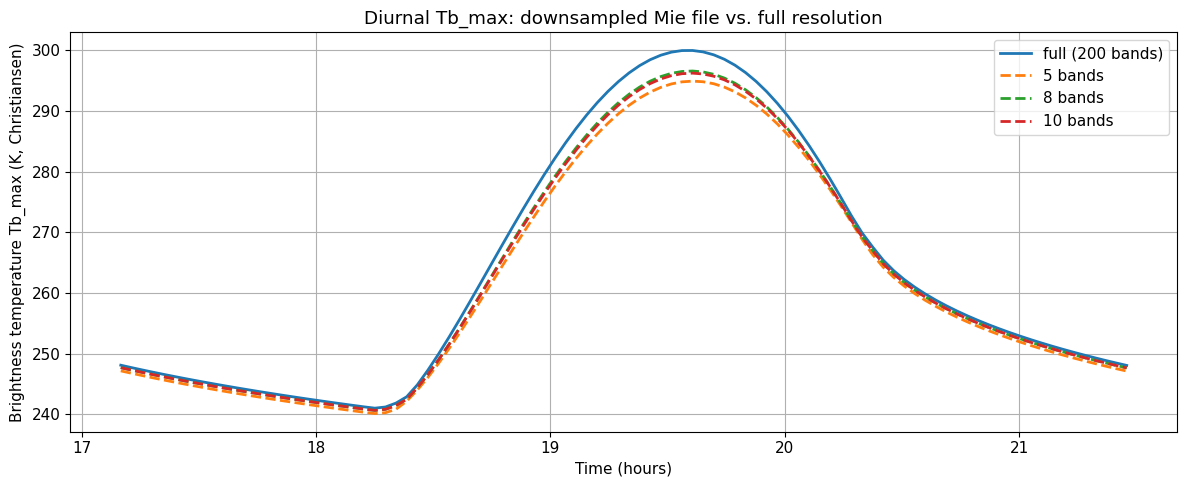

In [9]:
import time
from hybrid_calibration import downsample_mie_file, write_thermal_wn_bounds_file

downsample_results = {}
for n_bands in [5, 8, 10]:
    mie_ds, wnb_ds_full = downsample_mie_file(
        mie_file, wn_bounds_full, n_bands,
        f"../Optical_props/serpentine_downsampled_{n_bands}band.txt",
        f"../Optical_props/wn_bounds_serpentine_downsampled_{n_bands}band_full.txt",
    )
    wnb_ds = write_thermal_wn_bounds_file(
        wnb_ds_full, mie_ds, cfg_hybrid_calib.hybrid_wavelength_cutoff,
        f"../Optical_props/wn_bounds_serpentine_downsampled_{n_bands}band.txt",
    )
    t0 = time.time()
    result_ds = run_diurnal_comparison(
        cfg_hybrid_calib, mie_ds, ssalb_therm_mean, g_therm_mean,
        scale_Et=True, wn_bounds_file=wnb_ds, run_two_wave=False
    )
    elapsed = time.time() - t0
    max_diff_T_surf = float(np.max(np.abs(
        result_ds['T_surf_hybrid'] - real_spectral_result['T_surf_hybrid']
    )))
    max_diff_Tb_max = float(np.max(np.abs(
        result_ds['Tb_max_hybrid'] - real_spectral_result['Tb_max_hybrid']
    )))
    downsample_results[n_bands] = result_ds
    print(f"n_bands={n_bands:2d}: {elapsed:5.1f}s, "
          f"max abs T_surf diff vs full = {max_diff_T_surf:.4f} K, "
          f"max abs Tb_max diff vs full = {max_diff_Tb_max:.4f} K")

plt.figure(figsize=(12, 5))
plt.plot(t_hours, real_spectral_result['Tb_max_hybrid'], label='full (200 bands)', linewidth=2)
for n_bands, result_ds in downsample_results.items():
    plt.plot(t_hours, result_ds['Tb_max_hybrid'], label=f'{n_bands} bands', linestyle='--')
plt.xlabel('Time (hours)')
plt.ylabel('Brightness temperature Tb_max (K, Christiansen)')
plt.title('Diurnal Tb_max: downsampled Mie file vs. full resolution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Material comparison: serpentine vs. saponite

`saponite_mie_200wns_1um.txt` shares the same wavelength grid as the serpentine file, but is a
different mineral with its own Cext/ssalb/g spectrum. Since Et depends on the material's own
Cext, each material needs its own Et/eta calibration (same pattern as the serpentine section
above) for a fair comparison - same physical particle size/fill fraction, but the resulting
optical thickness of the same physical dust layer differs by material.

saponite: Et=133464.8, eta=8.3168, ssalb_therm_mean=0.1562, g_therm_mean=0.1391
serpentine (for reference): Et=130713.8, eta=8.4918, ssalb_therm_mean=0.3774, g_therm_mean=0.1394
Time step: 3.090124 s, Steps per day: 5000
Thermal evolution mode: two_wave
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/25000
Time step 10000/25000
Time step 11250/25000
Time step 12500/25000
Time step 13750/25000
Time step 15000/25000
Time step 16250/25000
Time step 17500/25000
Time step 18750/25000
Time step 20000/25000
Time step 21250/25000
Time step 22500/25000
Time step 23750/25000
Simulation completed in 3.67 s
Time step: 3.090124 s, Steps per day: 5000
Multi_wave mean Et rescaled to user input value!
Thermal evolution mode: hybrid
Time step 0/25000
Time step 1250/25000
Time step 2500/25000
Time step 3750/25000
Time step 5000/25000
Time step 6250/25000
Time step 7500/25000
Time step 8750/2500

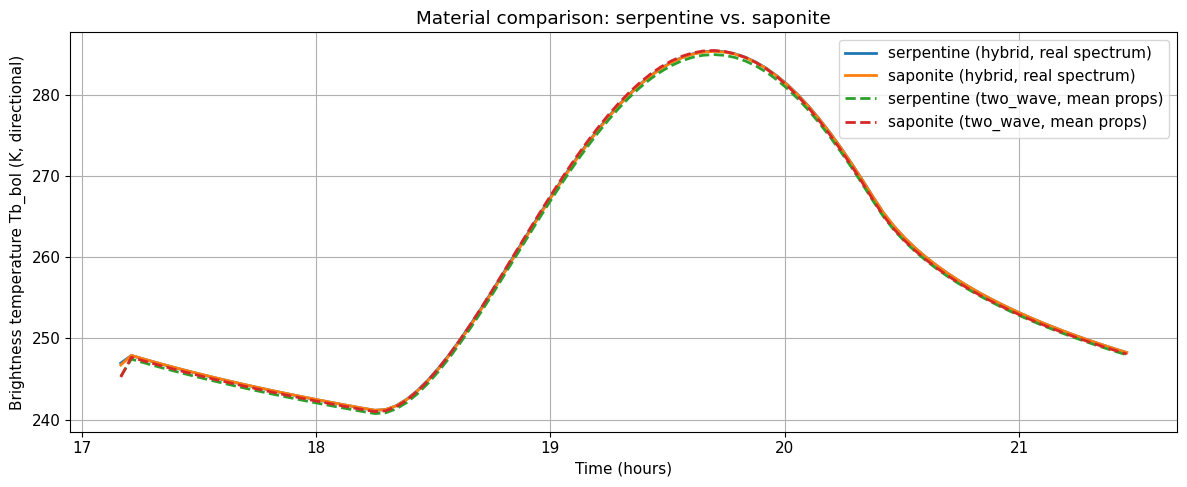

In [10]:
saponite_mie_file = '../Optical_props/saponite_mie_200wns_1um.txt'

cfg_saponite = copy.deepcopy(config1)
cfg_saponite.mie_file = saponite_mie_file
set_thermal_Et_from_mie(cfg_saponite, method='mean')
cfg_saponite, saponite_Et_vis = set_eta_geometric_optics(cfg_saponite)
saponite_wn_bounds_thermal = write_thermal_wn_bounds_file(
    wn_bounds_full, saponite_mie_file, cfg_saponite.hybrid_wavelength_cutoff,
    "../Optical_props/wn_bounds_200_thermal_saponite.txt"
)
cfg_saponite.wn_bounds = saponite_wn_bounds_thermal
saponite_ssalb_mean, saponite_g_mean = thermal_mean_properties(
    saponite_mie_file, cfg_saponite.hybrid_wavelength_cutoff
)
print(f"saponite: Et={cfg_saponite.Et:.1f}, eta={cfg_saponite.eta:.4f}, "
      f"ssalb_therm_mean={saponite_ssalb_mean:.4f}, g_therm_mean={saponite_g_mean:.4f}")
print(f"serpentine (for reference): Et={cfg_hybrid_calib.Et:.1f}, eta={cfg_hybrid_calib.eta:.4f}, "
      f"ssalb_therm_mean={ssalb_therm_mean:.4f}, g_therm_mean={g_therm_mean:.4f}")

saponite_result = run_diurnal_comparison(
    cfg_saponite, saponite_mie_file, saponite_ssalb_mean, saponite_g_mean, scale_Et=True
)
print(f"\nsaponite: two_wave (mean props) vs hybrid (real spectrum), fair checks: "
      f"max abs T_surf diff = {saponite_result['max_abs_T_surf_diff']:.4f} K, "
      f"max abs Tb_bol diff = {saponite_result['max_abs_Tb_bol_diff']:.4f} K")
print(f"serpentine (for reference): two_wave (mean props) vs hybrid (real spectrum), fair checks: "
      f"max abs T_surf diff = {real_spectral_result['max_abs_T_surf_diff']:.4f} K, "
      f"max abs Tb_bol diff = {real_spectral_result['max_abs_Tb_bol_diff']:.4f} K")

# Material comparisons below: serpentine vs saponite, same mode (hybrid-vs-hybrid, or
# two_wave-vs-two_wave) - a fair comparison for all metrics including Tb_max, since both
# sides have the same spectral resolution (or lack thereof).
diff_hybrid_materials_T_surf = float(np.max(np.abs(
    real_spectral_result['T_surf_hybrid'] - saponite_result['T_surf_hybrid']
)))
diff_hybrid_materials_Tb_bol = float(np.max(np.abs(
    real_spectral_result['Tb_bol_hybrid'] - saponite_result['Tb_bol_hybrid']
)))
diff_hybrid_materials_Tb_max = float(np.max(np.abs(
    real_spectral_result['Tb_max_hybrid'] - saponite_result['Tb_max_hybrid']
)))
diff_two_wave_materials_T_surf = float(np.max(np.abs(
    real_spectral_result['T_surf_two_wave'] - saponite_result['T_surf_two_wave']
)))
diff_two_wave_materials_Tb_bol = float(np.max(np.abs(
    real_spectral_result['Tb_bol_two_wave'] - saponite_result['Tb_bol_two_wave']
)))
print(f"\nserpentine vs saponite, full spectral hybrid: "
      f"max abs T_surf diff = {diff_hybrid_materials_T_surf:.4f} K, "
      f"max abs Tb_bol diff = {diff_hybrid_materials_Tb_bol:.4f} K, "
      f"max abs Tb_max diff = {diff_hybrid_materials_Tb_max:.4f} K")
print(f"serpentine vs saponite, two_wave (mean props): "
      f"max abs T_surf diff = {diff_two_wave_materials_T_surf:.4f} K, "
      f"max abs Tb_bol diff = {diff_two_wave_materials_Tb_bol:.4f} K")

plt.figure(figsize=(12, 5))
plt.plot(t_hours, real_spectral_result['Tb_bol_hybrid'], label='serpentine (hybrid, real spectrum)', linewidth=2)
plt.plot(t_hours, saponite_result['Tb_bol_hybrid'], label='saponite (hybrid, real spectrum)', linewidth=2)
plt.plot(t_hours, real_spectral_result['Tb_bol_two_wave'], label='serpentine (two_wave, mean props)', linestyle='--')
plt.plot(t_hours, saponite_result['Tb_bol_two_wave'], label='saponite (two_wave, mean props)', linestyle='--')
plt.xlabel('Time (hours)')
plt.ylabel('Brightness temperature Tb_bol (K, directional)')
plt.title('Material comparison: serpentine vs. saponite')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Plot RT thermal model diurnal model results

Old plots preserved here for posterity. 

In [ ]:
from matplotlib.ticker import FuncFormatter, LogLocator

# Plot temperature profiles vs depth (log scale) with a second y-axis for tau (opacity, non-log)
fig, ax1 = plt.subplots()
time_fracs = np.linspace(0, 1, len(sim1.t_out))
plot_fracs = np.linspace(0, 0.9, 10)
for frac in plot_fracs:
    idx = np.argmin(np.abs(time_fracs - frac))
    if hasattr(sim1.cfg.Et,'shape'):
        x_m = sim1.grid.x[1:] / sim1.cfg.Et[1:]
    else:
        x_m = sim1.grid.x[1:] / sim1.cfg.Et
    ax1.plot(T_out1[1:, idx], x_m, label=f't+{frac:.1f}P')

ax1.set_ylabel('Depth')
ax1.set_xlabel('Temperature (K)')
ax1.legend()
ax1.invert_yaxis()

# Set custom ticks for more human-readable units
def depth_formatter(x, pos):
    if x < 1e-3:
        return f"{x*1e6:.0f} µm"
    elif x < 1:
        return f"{x*1e3:.0f} mm"
    else:
        return f"{x:.0f} m"

ax1.set_yscale('log')
ax1.yaxis.set_major_locator(LogLocator(base=10))
ax1.yaxis.set_major_formatter(FuncFormatter(depth_formatter))

# Add a second y-axis for tau (opacity)
def tau_formatter(tau, pos):
    return f"{tau:.2f}"

# Create the secondary axis
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
# Convert the log-scale x_m limits back to tau
ylim = ax1.get_ylim()
if hasattr(sim1.cfg.Et,'shape'):
    tau_min = ylim[0] * sim1.cfg.Et[1]
    tau_max = ylim[1] * sim1.cfg.Et[-1]
else:
    tau_min = ylim[0] * sim1.cfg.Et
    tau_max = ylim[1] * sim1.cfg.Et
ax2.set_yscale('log')
ax2.set_ylim(tau_min, tau_max)
ax2.yaxis.set_major_locator(LogLocator(base=10))
ax2.yaxis.set_major_formatter(FuncFormatter(tau_formatter))
ax2.set_ylabel('Optical Depth (tau)')

plt.tight_layout()
plt.show()

## Plot diurnal brightness temperatures

`sim1` is a two_wave (single broadband thermal band) run, so `radiance*pi/sigma)**0.25` on its
own directional radiance is already the correct bolometric-directional brightness temperature -
there's only one band to sum over. This is exactly `bolometric_brightness_temperature_series`
from `hybrid_calibration.py` (used above for the hybrid comparisons), so we reuse it here rather
than duplicating the calculation - it generalizes automatically to multi-wave/hybrid sims if
`sim1` is ever swapped for one.

In [ ]:
from hybrid_calibration import bolometric_brightness_temperature_series

angles = [0, 60, 80]

for angle in angles:
    times, btemp = bolometric_brightness_temperature_series(sim1, observer_angle=angle)
    plt.plot(times, btemp, label=f'{angle:.0f}° from nadir', linewidth=2)

plt.ylabel('Brightness temperature (K)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)
plt.show()